## Metodología de entrenamiento — STGNN para pronóstico de temperatura (DMQ)

Recorrido ejecutable de la metodología usada para entrenar y comparar
**A3T-GCN** y **DCRNN** sobre la red REMMAQ. Cada sección corresponde a la del
capítulo de Desarrollo/Metodología del TFM (`metodologia_entrenamiento.md`) y
usa **artefactos y resultados ya generados** por
`src/features/preprocesamiento_canonico.py` y
`src/models/a3tgcn/entrenar_a3tgcn.py` / `src/models/dcrnn/entrenar_dcrnn.py` — no se reentrena
nada aquí, solo se cargan y documentan checkpoints, curvas y métricas reales.


### Configuración inicial


In [1]:
import sys, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import torch

sys.path.insert(0, '../src/models')
sys.path.insert(0, '../src/models/a3tgcn')
sys.path.insert(0, '../src/models/dcrnn')
import common as C
from entrenar_a3tgcn import ModeloA3TGCN
from entrenar_dcrnn import ModeloDCRNN

sns.set_theme(style='ticks', context='paper', font_scale=1.2)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 11

CMAP_SEQ = 'YlOrRd'
CMAP_DIV = 'RdBu_r'
COLOR_MODELO = {'A3T-GCN': '#2a78d6', 'DCRNN': '#e34948'}


def limpiar_ejes(ax, xlabel=None, ylabel=None, title=None):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if title is not None:
        ax.set_title(title, pad=8)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    return ax


ART_DIR = Path('../artefactos')
RES_A3T = Path('../resultados/a3tgcn')
RES_DCRNN = Path('../resultados/dcrnn')
RES_DM = Path('../resultados/diebold_mariano')

art = C.cargar_artefactos(ART_DIR)
tiempos = np.load(ART_DIR / 'tiempos.npy', allow_pickle=True)
tiempos = pd.to_datetime(tiempos)

print(f"Tensor X: {art['X'].shape}  (T, N, F)")
print(f"Estaciones: {art['station_order']}")
print(f"Features:   {art['feature_order']}")
print(f"Target: {art['feature_order'][art['target_idx']]} (idx {art['target_idx']})")


Tensor X: (159960, 6, 14)  (T, N, F)
Estaciones: ['Belisario', 'Carapungo', 'Cotocollao', 'ElCamal', 'LosChillos', 'Tumbaco']
Features:   ['temperaturaMedia', 'humedadRelativa', 'presionBarometrica', 'radiacionSolar', 'viento_u', 'viento_v', 'precipitacion_log', 'radiacionSolar_lag1', 'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'dia_semana_sin', 'dia_semana_cos']
Target: temperaturaMedia (idx 0)


## 1. Área de estudio y datos


In [2]:
resumen = {
    'Fuente': 'Red REMMAQ (DMQ)',
    'Estaciones (nodos)': f"{art['N']}: {', '.join(art['station_order'])}",
    'Rango temporal': f"{tiempos[0].date()} a {tiempos[-1].date()}",
    'Resolución': 'Horaria',
    'Pasos temporales (T)': f"{art['X'].shape[0]:,}",
    'Variable objetivo': f"`{art['feature_order'][art['target_idx']]}` (°C)",
    'Tensor final': f"(T={art['X'].shape[0]:,}, N={art['N']}, F={art['F']})",
}
pd.Series(resumen).to_frame('Valor')


,Valor
Fuente,Red REMMAQ (DMQ)
Estaciones (nodos),"6: Belisario, Carapungo, Cotocollao, ElCamal, ..."
Rango temporal,2008-01-01 a 2026-03-31
Resolución,Horaria
Pasos temporales (T),"159,960"
Variable objetivo,`temperaturaMedia` (°C)
Tensor final,"(T=159,960, N=6, F=14)"


## 2. Preprocesamiento y construcción del dataset

Selección de variables, escalado (ajustado **solo con train** para evitar
fuga de información hacia validación/test) y partición temporal.


### 2.1 Manifiesto de variables (14 features)


In [3]:
CLIMATICAS = art['feature_order'][:8]
CICLICAS = art['feature_order'][8:]

manifiesto = pd.DataFrame({
    'variable': art['feature_order'],
    'tipo': ['Climática'] * len(CLIMATICAS) + ['Cíclica'] * len(CICLICAS),
    'rol': (['Objetivo' if v == art['feature_order'][art['target_idx']]
             else 'Predictora' for v in CLIMATICAS])
           + ['Codificación temporal'] * len(CICLICAS),
    'escalada': ['Sí'] * len(CLIMATICAS) + ['No'] * len(CICLICAS),
})
manifiesto


,variable,tipo,rol,escalada
0,temperaturaMedia,Climática,Objetivo,Sí
1,humedadRelativa,Climática,Predictora,Sí
2,presionBarometrica,Climática,Predictora,Sí
3,radiacionSolar,Climática,Predictora,Sí
4,viento_u,Climática,Predictora,Sí
5,viento_v,Climática,Predictora,Sí
6,precipitacion_log,Climática,Predictora,Sí
7,radiacionSolar_lag1,Climática,Predictora,Sí
8,hora_sin,Cíclica,Codificación temporal,No
9,hora_cos,Cíclica,Codificación temporal,No


In [4]:
resumen_pre = json.load(open(ART_DIR / 'resumen_preprocesamiento.json'))
print("Variables descartadas y excluidas del manifiesto:")
print(f"  {resumen_pre['descartadas']}")


Variables descartadas y excluidas del manifiesto:
  ['hora', 'mes', 'dia_semana', 'anio', 'precipitacion', 'radiacionSolar_lag2', 'fecha']


### 2.2 Escalado (StandardScaler ajustado solo en train)


In [5]:
scaler = json.load(open(ART_DIR / 'scaler.json'))
tabla_scaler = pd.DataFrame({
    'variable': scaler['features'],
    'media (train)': np.round(scaler['mean'], 4),
    'desv. estándar (train)': np.round(scaler['scale'], 4),
})
tabla_scaler


,variable,media (train),desv. estándar (train)
0,temperaturaMedia,14.9559,3.6128
1,humedadRelativa,70.2994,19.5247
2,presionBarometrica,743.9572,17.3978
3,radiacionSolar,213.2026,307.8718
4,viento_u,0.1954,1.4374
5,viento_v,0.2560,1.2942
6,precipitacion_log,0.0530,0.2464
7,radiacionSolar_lag1,213.2026,307.8718


In [6]:
# Verificación: tras escalar, las climáticas deben tener media~0 y std~1 EN TRAIN
a, b = art['splits']['train']
chk = art['X'][a:b, :, :len(CLIMATICAS)].reshape(-1, len(CLIMATICAS))
print("Media  (climáticas, train, escalado):", np.round(chk.mean(axis=0), 3))
print("Std    (climáticas, train, escalado):", np.round(chk.std(axis=0), 3))
print("\nLas cíclicas (hora/mes/día sin-cos) NO se escalan: se rompería su geometría circular.")


Media  (climáticas, train, escalado): [-0.    -0.    -0.079  0.     0.    -0.    -0.     0.   ]
Std    (climáticas, train, escalado): [1.    1.    0.997 1.001 1.    1.    1.    1.001]

Las cíclicas (hora/mes/día sin-cos) NO se escalan: se rompería su geometría circular.


### 2.3 Partición temporal (cronológica, sin barajar)


In [7]:
filas = []
T = art['X'].shape[0]
for nombre, (a, b) in art['splits'].items():
    filas.append({
        'split': nombre,
        'inicio': tiempos[a].date(),
        'fin': tiempos[b - 1].date(),
        'pasos (T)': b - a,
        'proporción (%)': round((b - a) / T * 100, 1),
    })
pd.DataFrame(filas)


,split,inicio,fin,pasos (T),proporción (%)
0,train,2008-01-01,2021-12-31,122736,76.7
1,val,2022-01-01,2023-12-31,17520,11.0
2,test,2024-01-01,2026-03-31,19704,12.3


## 3. Definición del grafo

Nodos = estaciones (orden fijo, alfabético). Aristas ponderadas por proximidad
geográfica: kernel gaussiano sobre distancia Haversine,
$W_{ij} = \exp(-d_{ij}^2/\sigma^2)$, grafo totalmente conectado.


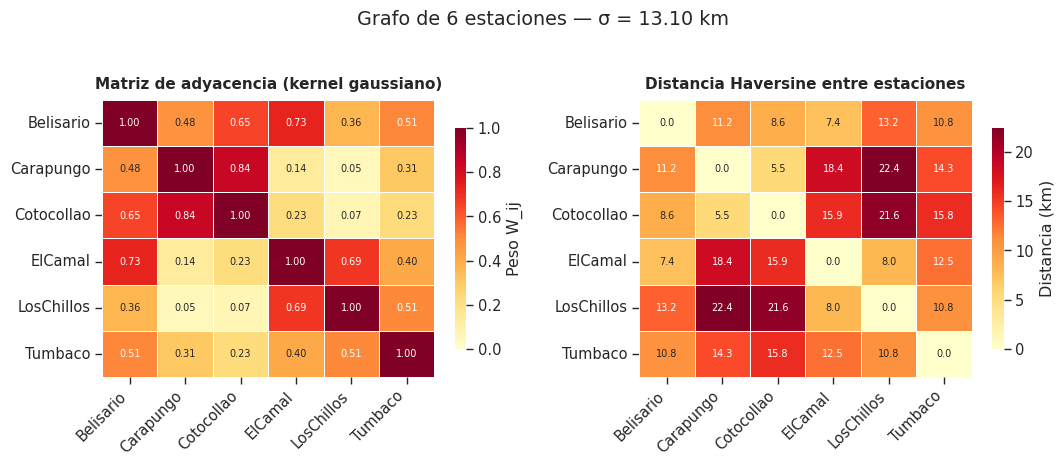

In [8]:
A = np.load(ART_DIR / 'adyacencia.npy')
D = np.load(ART_DIR / 'distancias_km.npy')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(A, ax=axes[0], cmap=CMAP_SEQ, vmin=0, vmax=1, annot=True, fmt='.2f',
            xticklabels=art['station_order'], yticklabels=art['station_order'],
            linewidths=0.4, linecolor='white', annot_kws={'size': 7},
            cbar_kws={'label': 'Peso W_ij', 'shrink': 0.8})
limpiar_ejes(axes[0], title='Matriz de adyacencia (kernel gaussiano)')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

sns.heatmap(D, ax=axes[1], cmap=CMAP_SEQ, annot=True, fmt='.1f',
            xticklabels=art['station_order'], yticklabels=art['station_order'],
            linewidths=0.4, linecolor='white', annot_kws={'size': 7},
            cbar_kws={'label': 'Distancia (km)', 'shrink': 0.8})
limpiar_ejes(axes[1], title='Distancia Haversine entre estaciones')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

fig.suptitle(f"Grafo de {art['N']} estaciones — σ = {resumen_pre['sigma_km']:.2f} km", y=1.03)
plt.tight_layout()
plt.show()


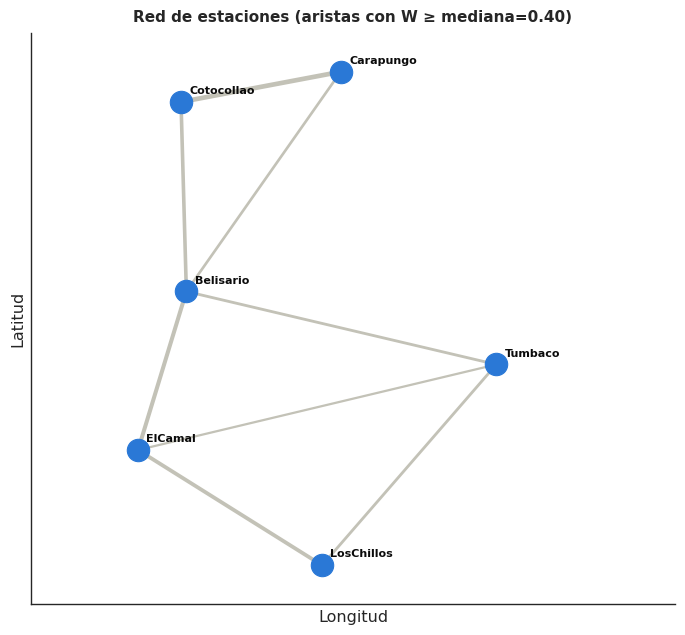

In [9]:
# Diagrama de red: posiciones = coordenadas reales (lon, lat); grosor/color de
# arista según el peso W_ij (solo se dibujan aristas con peso > mediana, para
# no saturar el diagrama con las 30 aristas dirigidas del grafo completo).
coords = pd.read_csv(ART_DIR / 'estaciones_coords_usadas.csv').set_index('estacion')
pos = {e: (coords.loc[e, 'lon'], coords.loc[e, 'lat']) for e in art['station_order']}

G = nx.Graph()
G.add_nodes_from(art['station_order'])
pesos_off_diag = A[~np.eye(art['N'], dtype=bool)]
umbral = np.median(pesos_off_diag)
for i, ei in enumerate(art['station_order']):
    for j, ej in enumerate(art['station_order']):
        if i < j and A[i, j] >= umbral:
            G.add_edge(ei, ej, weight=A[i, j])

fig, ax = plt.subplots(figsize=(7, 6.5))
edge_w = [G[u][v]['weight'] * 4 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=edge_w, edge_color='#c3c2b7', ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=260, node_color='#2a78d6', ax=ax)

# Etiquetas AL LADO del nodo (no adentro): a ese tamaño de marcador el nombre
# de estación no cabe dentro y queda cortado por los límites del eje.
lon_pad = (max(x for x, y in pos.values()) - min(x for x, y in pos.values())) * 0.05
for est, (x, y) in pos.items():
    ax.annotate(est, (x, y), xytext=(6, 6), textcoords='offset points',
                fontsize=8, fontweight='bold', color='#0b0b0b')

xs = [x for x, y in pos.values()]
ys = [y for x, y in pos.values()]
ax.set_xlim(min(xs) - 6 * lon_pad, max(xs) + 10 * lon_pad)
ax.set_ylim(min(ys) - 3 * lon_pad, max(ys) + 3 * lon_pad)
limpiar_ejes(ax, xlabel='Longitud', ylabel='Latitud',
             title=f'Red de estaciones (aristas con W ≥ mediana={umbral:.2f})')
plt.tight_layout()
plt.show()


## 4. Formulación del problema de pronóstico

Pronóstico directo (un modelo por horizonte): a partir de una ventana de
`seq_len` pasos se predice la temperatura `horizon` horas después. La ventana
de entrada se elige según la escala temporal de cada horizonte.


In [10]:
filas = []
for esc, h in C.HORIZONTES.items():
    filas.append({'escenario': esc, **h})
tabla_escenarios = pd.DataFrame(filas).set_index('escenario')
tabla_escenarios


,horizon,seq_len,batch
escenario,,,
corto,3,24,128
medio,48,96,64
largo,72,168,32


In [11]:
# Nº de ventanas válidas por split y escenario (sin cruzar fronteras train/val/test)
filas = []
for esc, h in C.HORIZONTES.items():
    fila = {'escenario': esc}
    for nombre, (a, b) in art['splits'].items():
        fila[nombre] = C.n_ventanas(b - a, h['seq_len'], h['horizon'])
    filas.append(fila)
pd.DataFrame(filas).set_index('escenario')


,train,val,test
escenario,,,
corto,122710,17494,19678
medio,122593,17377,19561
largo,122497,17281,19465


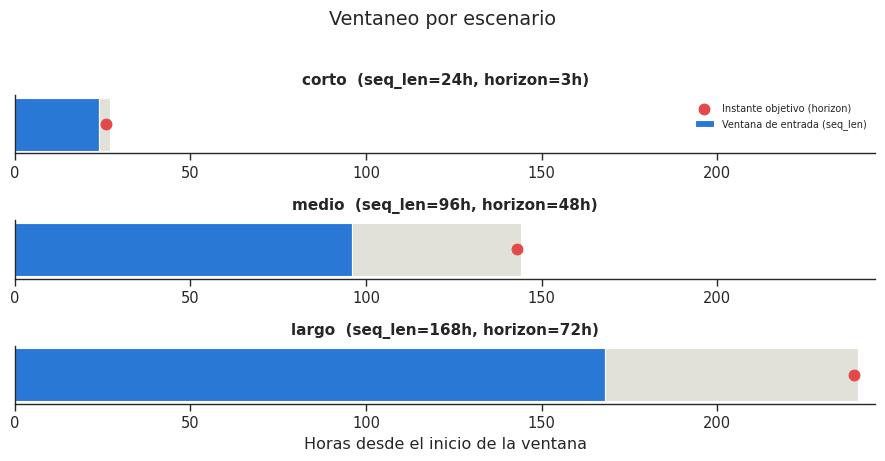

In [12]:
# Diagrama de ventaneo: ventana de entrada (seq_len) + salto hasta el target (horizon)
fig, axes = plt.subplots(len(C.HORIZONTES), 1, figsize=(9, 4.5))
for ax, (esc, h) in zip(axes, C.HORIZONTES.items()):
    L, hz = h['seq_len'], h['horizon']
    ax.barh(0, L, left=0, height=0.5, color='#2a78d6', label='Ventana de entrada (seq_len)')
    ax.barh(0, hz, left=L, height=0.5, color='#e1e0d9')
    ax.scatter([L + hz - 1], [0], color='#e34948', zorder=5, s=60,
               label='Instante objetivo (horizon)')
    ax.set_xlim(0, C.HORIZONTES['largo']['seq_len'] + C.HORIZONTES['largo']['horizon'] + 5)
    ax.set_yticks([])
    limpiar_ejes(ax, title=f"{esc}  (seq_len={L}h, horizon={hz}h)")
    if ax is axes[-1]:
        ax.set_xlabel('Horas desde el inicio de la ventana')

axes[0].legend(loc='upper right', frameon=False, fontsize=7)
fig.suptitle('Ventaneo por escenario', y=1.02)
plt.tight_layout()
plt.show()


## 5. Arquitecturas de los modelos

Ambas comparten cabeza de salida (ReLU + capa lineal) que proyecta el estado
oculto al valor del objetivo; difieren en cómo combinan la componente
espacial (grafo) y temporal (secuencia).


In [13]:
comparacion_arq = pd.DataFrame({
    'A3T-GCN': ['GCN sobre la topología del grafo', 'GRU + atención sobre los periods',
                '(N, F, seq_len)', 'Atención pondera todos los pasos',
                64, '—', 'Pondera qué instantes importan'],
    'DCRNN': ['Convolución por difusión (random-walk), orden K', 'GRU recurrente (paso a paso)',
              '(N, F) por paso, se recorren seq_len pasos', 'Estado oculto H arrastrado en la secuencia',
              64, 2, 'Captura inercia térmica secuencial'],
}, index=['Componente espacial', 'Componente temporal', 'Entrada por muestra',
          'Estado propagado', 'Canales ocultos', 'Orden de difusión K', 'Intuición'])
comparacion_arq


,A3T-GCN,DCRNN
Componente espacial,GCN sobre la topología del grafo,"Convolución por difusión (random-walk), orden K"
Componente temporal,GRU + atención sobre los periods,GRU recurrente (paso a paso)
Entrada por muestra,"(N, F, seq_len)","(N, F) por paso, se recorren seq_len pasos"
Estado propagado,Atención pondera todos los pasos,Estado oculto H arrastrado en la secuencia
Canales ocultos,64,64
Orden de difusión K,—,2
Intuición,Pondera qué instantes importan,Captura inercia térmica secuencial


In [14]:
# Nº de parámetros entrenables reales, por modelo y escenario (A3TGCN depende
# de 'periods'=seq_len via su módulo de atención; DCRNN no depende de seq_len).
edge_index = torch.as_tensor(art['edge_index'], dtype=torch.long)
edge_weight = torch.as_tensor(art['edge_weight'], dtype=torch.float32)

filas = []
for esc, h in C.HORIZONTES.items():
    m_a3t = ModeloA3TGCN(in_channels=art['F'], hidden=64, periods=h['seq_len'],
                          edge_index=edge_index, edge_weight=edge_weight)
    m_dcrnn = ModeloDCRNN(in_channels=art['F'], hidden=64, K=2,
                           edge_index=edge_index, edge_weight=edge_weight)
    filas.append({
        'escenario': esc,
        'params A3T-GCN': sum(p.numel() for p in m_a3t.parameters()),
        'params DCRNN': sum(p.numel() for p in m_dcrnn.parameters()),
    })
pd.DataFrame(filas).set_index('escenario')


,params A3T-GCN,params DCRNN
escenario,,
corto,27737,60161
medio,27809,60161
largo,27881,60161


## 6. Configuración experimental y entrenamiento

Hiperparámetros, función de pérdida, optimizador y criterio de parada
(idénticos para ambos modelos -> comparación justa).


In [15]:
hparams = pd.Series({
    'Función de pérdida': 'MSE (espacio escalado)',
    'Optimizador': 'Adam',
    'Learning rate': '1e-3',
    'Weight decay': '1e-5',
    'Recorte de gradiente': 'norma máx. 1.0',
    'Épocas máximas': 60,
    'Early stopping': 'paciencia 8 (sobre MAE de validación en °C)',
    'Canales ocultos': 64,
    'K (DCRNN)': 2,
    'Semilla': 42,
}, name='valor')
hparams.to_frame()


,valor
Función de pérdida,MSE (espacio escalado)
Optimizador,Adam
Learning rate,1e-3
Weight decay,1e-5
Recorte de gradiente,norma máx. 1.0
Épocas máximas,60
Early stopping,paciencia 8 (sobre MAE de validación en °C)
Canales ocultos,64
K (DCRNN),2
Semilla,42


### 6.1 Batching a nivel de grafo

Cada lote de $B$ ventanas se representa como un **único grafo disjunto**: los
nodos del elemento $k$ se desplazan $+k \cdot N$ y las aristas se replican con
el mismo desplazamiento — así una sola llamada al modelo procesa el lote
completo. Demostración con un lote pequeño ($B=3$) sobre el grafo real:


In [16]:
B_demo = 3
ei_b, ew_b = C.construir_grafo_batch(edge_index, edge_weight, B_demo, art['N'])
print(f"Grafo estático:  edge_index {tuple(edge_index.shape)}, edge_weight {tuple(edge_weight.shape)}")
print(f"Grafo por lote (B={B_demo}): edge_index {tuple(ei_b.shape)}, edge_weight {tuple(ew_b.shape)}")
print(f"\nPrimeras aristas del nodo 0 del elemento k=1 del lote "
      f"(desplazadas +1*{art['N']}={art['N']}):")
print(ei_b[:, edge_index.shape[1]:edge_index.shape[1] + 3].T.tolist())


Grafo estático:  edge_index (2, 30), edge_weight (30,)
Grafo por lote (B=3): edge_index (2, 90), edge_weight (90,)

Primeras aristas del nodo 0 del elemento k=1 del lote (desplazadas +1*6=6):
[[6, 7], [6, 8], [6, 9]]


### 6.2 Curvas de convergencia (entrenamiento real, ya ejecutado)


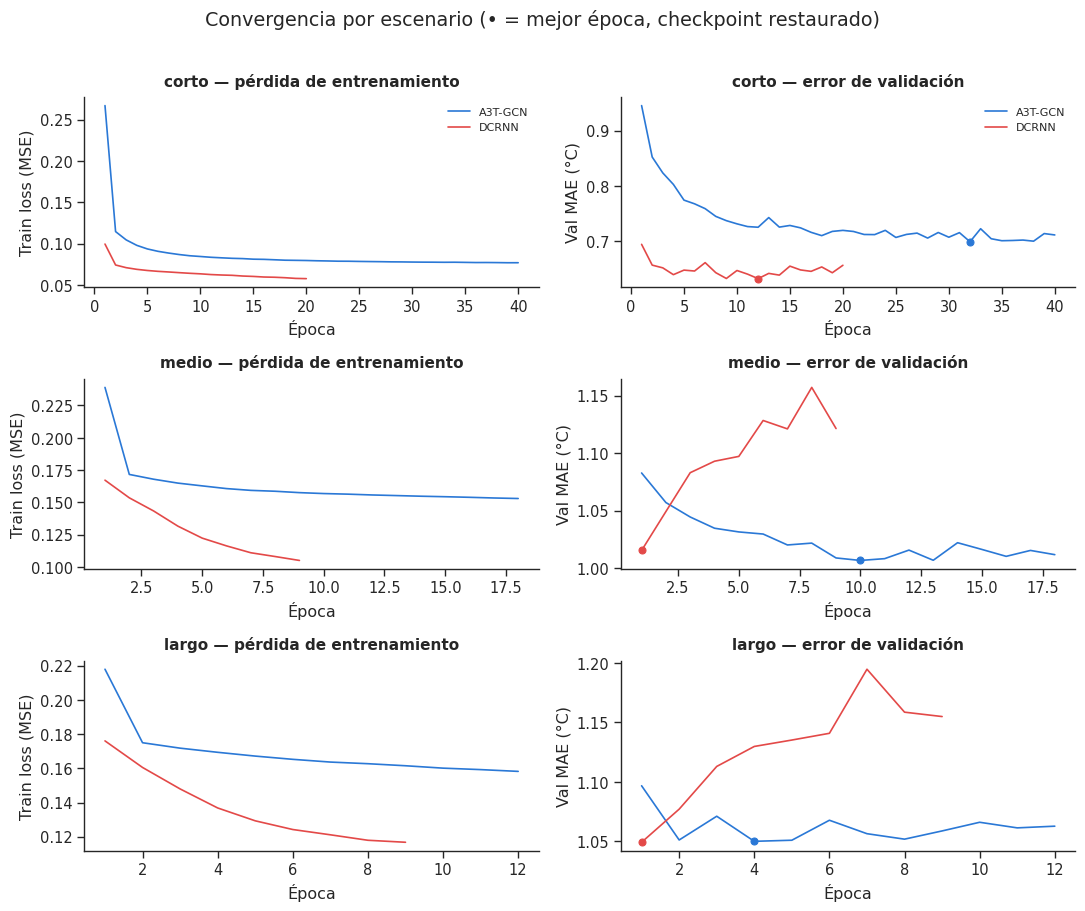

In [17]:
def cargar_convergencia(res_dir, prefijo, esc, h):
    path = res_dir / f"{prefijo}_{esc}_h{h['horizon']}_convergencia.csv"
    return pd.read_csv(path)

fig, axes = plt.subplots(len(C.HORIZONTES), 2, figsize=(11, 3 * len(C.HORIZONTES)))
for i, (esc, h) in enumerate(C.HORIZONTES.items()):
    conv_a3t = cargar_convergencia(RES_A3T, 'a3tgcn', esc, h)
    conv_dcrnn = cargar_convergencia(RES_DCRNN, 'dcrnn', esc, h)

    ax_loss, ax_mae = axes[i]
    for conv, modelo in [(conv_a3t, 'A3T-GCN'), (conv_dcrnn, 'DCRNN')]:
        ax_loss.plot(conv['epoch'], conv['train_loss'], color=COLOR_MODELO[modelo],
                     label=modelo, linewidth=1.2)
        ax_mae.plot(conv['epoch'], conv['val_mae_C'], color=COLOR_MODELO[modelo],
                    label=modelo, linewidth=1.2)
        best_ep = conv.loc[conv['val_mae_C'].idxmin()]
        ax_mae.scatter([best_ep['epoch']], [best_ep['val_mae_C']],
                       color=COLOR_MODELO[modelo], zorder=5, s=25)

    limpiar_ejes(ax_loss, xlabel='Época', ylabel='Train loss (MSE)',
                 title=f'{esc} — pérdida de entrenamiento')
    limpiar_ejes(ax_mae, xlabel='Época', ylabel='Val MAE (°C)',
                 title=f'{esc} — error de validación')
    if i == 0:
        ax_loss.legend(frameon=False, fontsize=8)
        ax_mae.legend(frameon=False, fontsize=8)

fig.suptitle('Convergencia por escenario (• = mejor época, checkpoint restaurado)', y=1.01)
plt.tight_layout()
plt.show()


In [18]:
# Tiempo de entrenamiento real (columna 'seg' de cada curva de convergencia)
filas = []
for esc, h in C.HORIZONTES.items():
    for res_dir, prefijo, modelo in [(RES_A3T, 'a3tgcn', 'A3T-GCN'), (RES_DCRNN, 'dcrnn', 'DCRNN')]:
        conv = cargar_convergencia(res_dir, prefijo, esc, h)
        filas.append({
            'escenario': esc, 'modelo': modelo,
            'épocas corridas': len(conv), 'épocas máx.': 60,
            'seg/época (media)': round(conv['seg'].mean(), 1),
            'tiempo total (min)': round(conv['seg'].sum() / 60, 1),
        })
pd.DataFrame(filas).set_index(['escenario', 'modelo'])


épocas corridas  épocas máx.  seg/época (media)  \
escenario modelo                                                     
corto     A3T-GCN               40           60              117.7   
          DCRNN                 20           60              160.7   
medio     A3T-GCN               18           60              761.1   
          DCRNN                  9           60             1191.3   
largo     A3T-GCN               12           60             2587.2   
          DCRNN                  9           60             4056.6   

                   tiempo total (min)  
escenario modelo                       
corto     A3T-GCN                78.4  
          DCRNN                  53.6  
medio     A3T-GCN               228.3  
          DCRNN                 178.7  
largo     A3T-GCN               517.4  
          DCRNN                 608.5

## 7. Métricas de evaluación

Todas se calculan sobre valores **desescalados a °C**, a nivel global y por
estación (ver `common.metricas` / `common.metricas_por_estacion`).

| Métrica | Fórmula | Nota |
|---|---|---|
| MAE  | $\frac{1}{n}\sum\lvert\hat y-y\rvert$ | Error medio en °C |
| RMSE | $\sqrt{\frac{1}{n}\sum(\hat y-y)^2}$ | Penaliza errores grandes |
| R²   | $1-\frac{\sum(\hat y-y)^2}{\sum(y-\bar y)^2}$ | Varianza explicada |
| MAPE | $\frac{100}{n}\sum\frac{\lvert\hat y-y\rvert}{\max(\lvert y\rvert,\varepsilon)}$ | $\varepsilon=10^{-2}$; cauteloso cerca de 0 °C |


In [19]:
met_a3t = json.load(open(RES_A3T / 'metricas_a3tgcn.json'))
met_dcrnn = json.load(open(RES_DCRNN / 'metricas_dcrnn.json'))

filas = []
for esc in C.HORIZONTES:
    for met, modelo in [(met_a3t, 'A3T-GCN'), (met_dcrnn, 'DCRNN')]:
        g = met[esc]['global']
        filas.append({'escenario': esc, 'modelo': modelo, **{k: round(v, 4) for k, v in g.items()}})
tabla_metricas = pd.DataFrame(filas).set_index(['escenario', 'modelo'])
tabla_metricas


MAE    RMSE      R2    MAPE
escenario modelo                                 
corto     A3T-GCN  0.7233  1.0166  0.9147  4.6897
          DCRNN    0.6573  0.9458  0.9262  4.2662
medio     A3T-GCN  1.0484  1.4110  0.8360  6.9318
          DCRNN    1.0401  1.4054  0.8373  6.8815
largo     A3T-GCN  1.1085  1.4758  0.8207  7.2876
          DCRNN    1.0940  1.4536  0.8261  7.1646

## 8. Protocolo de comparación y significancia estadística

Comparación con **base idéntica** (mismo preprocesador canónico, mismo
ventaneo, mismas métricas); la superioridad se contrasta con el test de
Diebold-Mariano sobre las predicciones de test.


In [20]:
dm = pd.read_csv(RES_DM / 'dm_resumen.csv')
dm


,escenario,h,mae_A3T,mae_DCRNN,dm_stat,p_value,veredicto
0,corto,3,0.723338,0.657270,20.367332,2.844869e-91,DCRNN mejor
1,medio,48,1.048440,1.040084,1.028634,3.036643e-01,equivalentes
2,largo,72,1.108525,1.093958,1.401040,1.612181e-01,equivalentes


## 9. Entorno de cómputo y reproducibilidad


In [21]:
import platform
import torch_geometric_temporal as tgt

entorno = pd.Series({
    'SO': platform.system(),
    'Python': platform.python_version(),
    'PyTorch': torch.__version__,
    'CUDA disponible': torch.cuda.is_available(),
    'GPU': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A',
    'torch-geometric-temporal': tgt.__version__,
    'Semilla': 42,
    'Artefactos versionados': 'X.npy, edge_index.npy, edge_weight.npy, splits.json, scaler.json',
}, name='valor')
entorno.to_frame()


,valor
SO,Linux
Python,3.10.12
PyTorch,2.1.2+cu121
CUDA disponible,True
GPU,NVIDIA GeForce RTX 4050 Laptop GPU
torch-geometric-temporal,0.54.0
Semilla,42
Artefactos versionados,"X.npy, edge_index.npy, edge_weight.npy, splits..."
